# 04 - Structural Filtering, Chunk-Level (ContraDoc)

KG-pattern queries that surface candidate contradiction pairs. Patterns operate on `:Entity`-`:RELATION`-`:Entity` triples but aggregate matched triple pairs to **unique chunk pairs** via `sentence_id`s, so output is directly comparable with step 05's vector retrieval.

## Patterns (S-SR / S-SO / S-Union)

Both baseline patterns include a MinIE-aware disjunct that recovers the signal MinIE-style normalization hid from naive 02 extraction:

- **S-SR** - same subject + same predicate, different relation outcome. "Different outcome" means **either** different object **or** same object with different quantity. The quantity disjunct is needed because notebook 02b normalizes cardinal expressions ("9 cats" -> `o="Q cats", quantity="9"`); under naive 02 extraction the cardinal stayed inside `o`, so different quantities meant different objects, which S-SR caught. With MinIE the two triples now share `o`, so we read the difference off `quantity` instead.
- **S-SO** - same subject + same object, different relation. "Different relation" means **either** different predicate string **or** same predicate with flipped polarity. The polarity disjunct is needed because notebook 02b normalizes predicates to their affirmative form (e.g., 'make_a_deal_with' regardless of "did" vs "did not"); under naive 02 extraction, negation showed up as a different predicate string, so S-SO caught it. With MinIE the difference moves into `polarity`.
- **S-Union** = S-SR ∪ S-SO.

Both queries exclude same-sentence matches (`r1.sentence_id <> r2.sentence_id`) since the pipeline retrieves chunk pairs.

**Why not include modality and attribution.** Modality (`CT` vs `PS`) is a degree-of-certainty difference - "X may have happened" and "X happened" are not contradictory, just less- or more-certain assertions. Attribution is a who-said-it difference - two sources reporting the same claim is not a contradiction; only the underlying claim conflicting is, which is already caught by S-SR / S-SO. Pilot ablations on the 150-doc KG confirmed both patterns fire rarely and catch zero gold pairs.

**Output:** `data/processed/ContraDoc/structural_candidates.jsonl` - one JSON object per candidate chunk pair.

In [1]:
import json
from collections import defaultdict
from pathlib import Path

from neo4j import GraphDatabase

from config import settings

OUTPUT_PATH = Path("data/processed/ContraDoc/structural_candidates.jsonl")

## Connect to Neo4j and pull chunks / gold pairs

In [2]:
driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password.get_secret_value()),
)
driver.verify_connectivity()


def run(cypher, **params):
    with driver.session() as s:
        return list(s.run(cypher, **params))


n_docs = run("MATCH (d:Document) RETURN count(d) AS n")[0]["n"]
n_chunks = run("MATCH (c:Chunk) RETURN count(c) AS n")[0]["n"]
n_rels = run("MATCH ()-[r:RELATION]->() RETURN count(r) AS n")[0]["n"]
print(f"Connected. {n_docs} documents, {n_chunks} chunks, {n_rels} :RELATION edges.")

chunks = [
    dict(r)
    for r in run(
        "MATCH (c:Chunk) RETURN c.doc_id AS doc_id, c.sentence_id AS sid, c.source_text AS text, "
        "c.is_gold_evidence AS is_gold_evidence, c.is_gold_ref AS is_gold_ref, c.ref_index AS ref_index"
    )
]
chunk_by_key = {(c["doc_id"], c["sid"]): c for c in chunks}
doc_label = {r["d"]: r["l"] for r in run("MATCH (d:Document) RETURN d.doc_id AS d, d.contradiction AS l")}


def pkey(a, b):
    return (a, b) if a < b else (b, a)


gold_pairs = set()
for ev in chunks:
    if not ev["is_gold_evidence"]:
        continue
    for ref in chunks:
        if ref["is_gold_ref"] and ref["doc_id"] == ev["doc_id"]:
            gold_pairs.add(pkey((ev["doc_id"], ev["sid"]), (ref["doc_id"], ref["sid"])))

n_gold_usable_docs = len({p[0][0] for p in gold_pairs})
print(f"Gold chunk pairs: {len(gold_pairs)} across {n_gold_usable_docs} docs")

Connected. 150 documents, 5651 chunks, 9189 :RELATION edges.
Gold chunk pairs: 127 across 123 docs


## S-SR / S-SO queries returning DISTINCT chunk pairs

In [3]:
# S-SR: same s, same p, different relation outcome.
# "Different outcome" = different object OR same object with different quantity.
# The quantity disjunct recovers the numeric case that MinIE's "Q" placeholder
# normalization hid from naive same-o, different-o matching.
S_SR = """
MATCH (s:Entity)-[r1:RELATION]->(o1:Entity), (s)-[r2:RELATION]->(o2:Entity)
WHERE r1.doc_id = r2.doc_id
  AND r1.predicate = r2.predicate
  AND elementId(r1) < elementId(r2)
  AND r1.sentence_id <> r2.sentence_id
  AND (
    o1.name <> o2.name
    OR (r1.quantity IS NOT NULL AND r2.quantity IS NOT NULL AND r1.quantity <> r2.quantity)
  )
RETURN DISTINCT r1.doc_id AS doc_id, r1.sentence_id AS sid_a, r2.sentence_id AS sid_b
"""

# S-SO: same s, same o, different relation.
# "Different relation" = different predicate OR same predicate with flipped
# polarity. The polarity disjunct recovers the negation case that MinIE's
# affirmative-form predicate normalization hid.
S_SO = """
MATCH (s:Entity)-[r1:RELATION]->(o:Entity), (s)-[r2:RELATION]->(o)
WHERE r1.doc_id = r2.doc_id
  AND elementId(r1) < elementId(r2)
  AND r1.sentence_id <> r2.sentence_id
  AND (r1.predicate <> r2.predicate OR r1.polarity <> r2.polarity)
RETURN DISTINCT r1.doc_id AS doc_id, r1.sentence_id AS sid_a, r2.sentence_id AS sid_b
"""


def query_to_pairs(cypher: str) -> set:
    """Run a structural query and return the canonicalized set of chunk-pair keys."""
    pairs = set()
    for r in run(cypher):
        a, b = pkey((r["doc_id"], r["sid_a"]), (r["doc_id"], r["sid_b"]))
        pairs.add((a, b))
    return pairs


sr_pairs = query_to_pairs(S_SR)
so_pairs = query_to_pairs(S_SO)
union_pairs = sr_pairs | so_pairs

print(f"S-SR  chunk pairs: {len(sr_pairs)}")
print(f"S-SO  chunk pairs: {len(so_pairs)}")
print(f"S-Union chunk pairs: {len(union_pairs)}")

S-SR  chunk pairs: 476
S-SO  chunk pairs: 415
S-Union chunk pairs: 878


## Evaluation

In [4]:
def evaluate(pairs: set, name: str) -> dict:
    caught = pairs & gold_pairs
    docs_caught = {p[0][0] for p in caught}
    per_doc = defaultdict(int)
    for a, _ in pairs:
        per_doc[a[0]] += 1
    yes_vol = [per_doc.get(d, 0) for d, l in doc_label.items() if l == "YES"]
    no_vol = [per_doc.get(d, 0) for d, l in doc_label.items() if l == "NO"]
    return {
        "name": name,
        "n": len(pairs),
        "caught": len(caught),
        "pair_r": len(caught) / max(len(gold_pairs), 1),
        "doc_r": len(docs_caught) / max(n_gold_usable_docs, 1),
        "docs_caught": len(docs_caught),
        "prec": len(caught) / max(len(pairs), 1),
        "yes_mean": sum(yes_vol) / max(len(yes_vol), 1),
        "no_mean": sum(no_vol) / max(len(no_vol), 1),
    }


rows = [evaluate(sr_pairs, "S-SR"), evaluate(so_pairs, "S-SO"), evaluate(union_pairs, "S-Union")]
print(f"Gold chunk pairs: {len(gold_pairs)} across {n_gold_usable_docs} docs")
print()
header = f"{'Method':10} {'#cand':>6}  {'caught':>6}  {'Pair-R':>7}  {'Doc-R':>11}  {'Prec':>6}  {'YES mean':>9}  {'NO mean':>9}"
print(header)
print("-" * len(header))
for r in rows:
    print(
        f"{r['name']:10} {r['n']:>6}  {r['caught']:>6}  "
        f"{r['pair_r']:>6.1%}  "
        f"{r['docs_caught']:>3}/{n_gold_usable_docs:<3} {r['doc_r']:>5.1%}  "
        f"{r['prec']:>5.1%}  "
        f"{r['yes_mean']:>8.1f}  {r['no_mean']:>8.1f}"
    )

Gold chunk pairs: 127 across 123 docs

Method      #cand  caught   Pair-R        Doc-R    Prec   YES mean    NO mean
-----------------------------------------------------------------------------
S-SR          476      29   22.8%   29/123 23.6%   6.1%       3.2       0.0
S-SO          415      27   21.3%   27/123 22.0%   6.5%       2.8       0.0
S-Union       878      55   43.3%   55/123 44.7%   6.3%       5.9       0.0


## Save S-Union chunk pairs

In [5]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    for key_a, key_b in union_pairs:
        ca, cb = chunk_by_key[key_a], chunk_by_key[key_b]
        pattern = "S-SR+S-SO" if (key_a, key_b) in (sr_pairs & so_pairs) else "S-SR" if (key_a, key_b) in sr_pairs else "S-SO"
        rec = {
            "doc_id": ca["doc_id"],
            "pattern": pattern,
            "is_gold_pair": (key_a, key_b) in gold_pairs,
            "chunk_a": {
                "sentence_id": ca["sid"],
                "source_text": ca["text"],
                "is_gold_evidence": ca["is_gold_evidence"],
                "is_gold_ref": ca["is_gold_ref"],
            },
            "chunk_b": {
                "sentence_id": cb["sid"],
                "source_text": cb["text"],
                "is_gold_evidence": cb["is_gold_evidence"],
                "is_gold_ref": cb["is_gold_ref"],
            },
        }
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print(f"Saved {len(union_pairs)} S-Union chunk pairs -> {OUTPUT_PATH.resolve()}")

caught_sr = [p for p in sr_pairs if p in gold_pairs]
caught_so = [p for p in so_pairs if p in gold_pairs]
for label, caught in [("S-SR", caught_sr), ("S-SO", caught_so)]:
    print()
    print(f"Sample caught gold pair ({label}, n={len(caught)}):")
    if caught:
        key_a, key_b = caught[0]
        ca, cb = chunk_by_key[key_a], chunk_by_key[key_b]
        tag_a = "EV" if ca["is_gold_evidence"] else ("REF" if ca["is_gold_ref"] else "  ")
        tag_b = "EV" if cb["is_gold_evidence"] else ("REF" if cb["is_gold_ref"] else "  ")
        print(f"  doc_id={ca['doc_id']}")
        print(f"  [{tag_a}] sid={ca['sid']}: {ca['text'][:140]}")
        print(f"  [{tag_b}] sid={cb['sid']}: {cb['text'][:140]}")

driver.close()

Saved 878 S-Union chunk pairs -> D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\structural_candidates.jsonl

Sample caught gold pair (S-SR, n=29):
  doc_id=3503017434_4
  [REF] sid=8: Benthic in nature , the plain maskray feeds mainly on caridean shrimp and polychaete worms , and to a lesser extent on small bony fishes.
  [EV] sid=38: The plain maskray feeds mainly on large bony fishes and cephalopods.

Sample caught gold pair (S-SO, n=27):
  doc_id=3499318678_3
  [REF] sid=9: Campbell 's filters were far superior to the simpler single element circuits that had been used previously.
  [EV] sid=11: Campbell's filters were not superior to the simpler single element circuits that had been used previously.


## Per-type recall breakdown

How well does each structural pattern recover gold pairs for each ContraDoc contradiction type? Multi-label docs (e.g., `Content|Numeric`) contribute to every listed type.

In [6]:
_driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password.get_secret_value()),
)
with _driver.session() as _s:
    doc_types = {
        r["doc_id"]: [t for t in (r["contra_type"] or "none").split("|") if t]
        for r in _s.run("MATCH (d:Document {contradiction: 'YES'}) RETURN d.doc_id AS doc_id, d.contra_type AS contra_type")
    }
_driver.close()


def per_type_recall(pairs, name):
    type_totals = defaultdict(int)
    type_caught = defaultdict(int)
    for p in gold_pairs:
        doc_id = p[0][0]
        for t in doc_types.get(doc_id, ["unknown"]):
            type_totals[t] += 1
            if p in pairs:
                type_caught[t] += 1
    all_types = sorted(type_totals.keys(), key=lambda x: -type_totals[x])
    print(f"\n{name}:")
    print(f"  {'type':30s}  caught  total  recall")
    print("  " + "-" * 52)
    for t in all_types:
        caught, total = type_caught[t], type_totals[t]
        print(f"  {t:30s}  {caught:>6}  {total:>5}  {caught / max(total, 1):>6.1%}")


for name, pairs in [("S-SR", sr_pairs), ("S-SO", so_pairs), ("S-Union", union_pairs)]:
    per_type_recall(pairs, name)


S-SR:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             18     78   23.1%
  Perspective/View/Opinion             5     38   13.2%
  Negation                             1     34    2.9%
  Emotion/Mood/Feeling                 2     32    6.2%
  Numeric                             14     22   63.6%
  Factual                              9     20   45.0%
  Relation                             1     15    6.7%
  Causal                               0      7    0.0%

S-SO:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             11     78   14.1%
  Perspective/View/Opinion             7     38   18.4%
  Negation                            13     34   38.2%
  Emotion/Mood/Feeling                 6     32   18.8%
  Numeric                              1     22    4.5%
  Factual                           

## Plots

Visualize structural-retrieval performance: per-method recall / precision and per-contra-type recall. PNGs saved to `plots/04_structural_filtering/`.

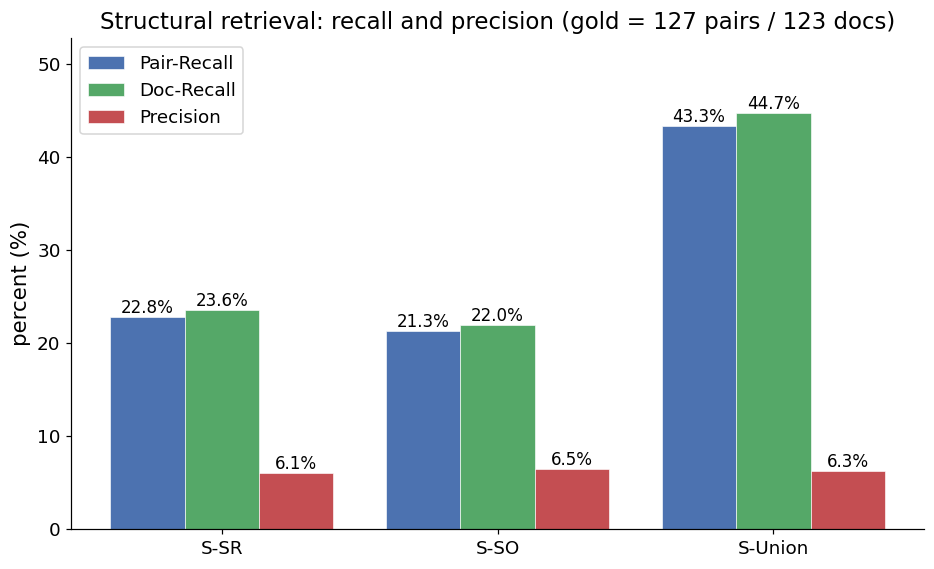

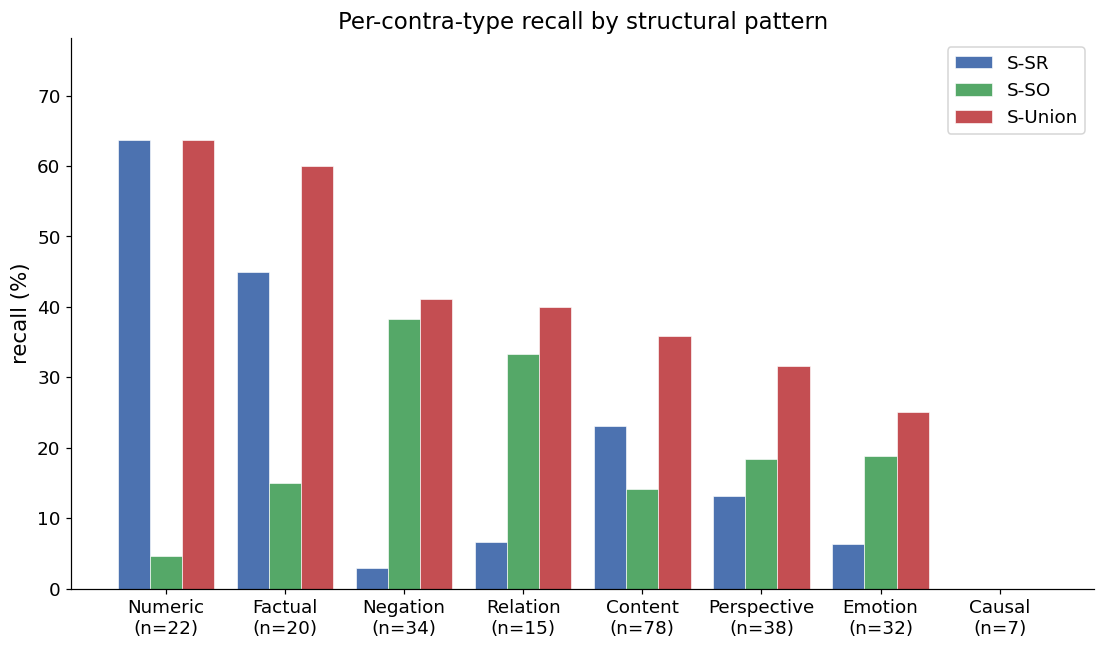

Saved 2 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\04_structural_filtering


In [7]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = Path("plots/04_structural_filtering")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"

# --- Plot 1: Pair-R / Doc-R / Precision per method ---
methods = ["S-SR", "S-SO", "S-Union"]
method_pairs = [sr_pairs, so_pairs, union_pairs]
metrics = {"Pair-R": [], "Doc-R": [], "Precision": []}
for p in method_pairs:
    e = evaluate(p, "")
    metrics["Pair-R"].append(e["pair_r"] * 100)
    metrics["Doc-R"].append(e["doc_r"] * 100)
    metrics["Precision"].append(e["prec"] * 100)
x = np.arange(len(methods))
w = 0.27
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.bar(x - w, metrics["Pair-R"], w, label="Pair-Recall", color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.bar(x,     metrics["Doc-R"],  w, label="Doc-Recall",  color=C_GREEN, edgecolor="white", linewidth=0.4)
ax.bar(x + w, metrics["Precision"], w, label="Precision", color=C_RED, edgecolor="white", linewidth=0.4)
for i, m in enumerate(methods):
    ax.text(i - w, metrics["Pair-R"][i],    f"{metrics['Pair-R'][i]:.1f}%",    ha="center", va="bottom", fontsize=11)
    ax.text(i,     metrics["Doc-R"][i],     f"{metrics['Doc-R'][i]:.1f}%",     ha="center", va="bottom", fontsize=11)
    ax.text(i + w, metrics["Precision"][i], f"{metrics['Precision'][i]:.1f}%", ha="center", va="bottom", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("percent (%)")
ax.set_title(f"Structural retrieval: recall and precision (gold = {len(gold_pairs)} pairs / {n_gold_usable_docs} docs)")
ax.set_ylim(0, max(max(v) for v in metrics.values()) * 1.18)
ax.legend(loc="upper left")
fig.savefig(PLOT_DIR / "method_metrics.png")
plt.show()

# --- Plot 2: per-contra-type recall ---
type_order = ["Numeric", "Factual", "Negation", "Relation", "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
type_totals = {t: 0 for t in type_order}
for p in gold_pairs:
    for t in doc_types.get(p[0][0], []):
        if t in type_totals:
            type_totals[t] += 1

def _recall(pairs):
    caught = {t: 0 for t in type_order}
    for p in gold_pairs:
        if p in pairs:
            for t in doc_types.get(p[0][0], []):
                if t in caught:
                    caught[t] += 1
    return [caught[t] / max(type_totals[t], 1) * 100 for t in type_order]

sr_recall = _recall(sr_pairs)
so_recall = _recall(so_pairs)
un_recall = _recall(union_pairs)
x = np.arange(len(type_order))
w = 0.27
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(x - w, sr_recall, w, label="S-SR",    color=C_BLUE,  edgecolor="white", linewidth=0.4)
ax.bar(x,     so_recall, w, label="S-SO",    color=C_GREEN, edgecolor="white", linewidth=0.4)
ax.bar(x + w, un_recall, w, label="S-Union", color=C_RED,   edgecolor="white", linewidth=0.4)
ax.set_xticks(x)
short = {
    "Perspective/View/Opinion": "Perspective",
    "Emotion/Mood/Feeling": "Emotion",
}
ax.set_xticklabels(
    [f"{short.get(t, t)}\n(n={type_totals[t]})" for t in type_order],
    rotation=0,
)
ax.set_ylabel("recall (%)")
ax.set_title("Per-contra-type recall by structural pattern")
ymax = max(max(sr_recall), max(so_recall), max(un_recall))
ax.set_ylim(0, ymax * 1.15 + 5)
ax.legend(loc="upper right")
fig.savefig(PLOT_DIR / "per_type_recall.png")
plt.show()

print(f"Saved 2 plots to {PLOT_DIR.resolve()}")